# Visualisation des résultats du clustering

Analyse et visualisation du modèle K-Means entraîné sur le **Wholesale Customers Dataset**.

## 1. Imports et chargement des données

In [51]:
import sys
import os
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans, DBSCAN

from src.data import load_data, preprocess, NUMERIC_COLS
from src.train import DATA_URL

sns.set_theme(style="whitegrid")

# Pointer vers le mlruns à la racine du projet
mlflow.set_tracking_uri(f"file://{os.path.abspath('../mlruns')}")

# Charger et prétraiter les données
df_raw = load_data(DATA_URL)
df_scaled, scaler = preprocess(df_raw)

# Charger le modèle depuis MLflow
from src.predict import load_model
model, run_id = load_model()
labels = model.predict(df_scaled)
df_raw["Cluster"] = labels

print(f"Run MLflow : {run_id}")
print(f"Nombre de clusters : {model.n_clusters}")
print(f"Nombre d'échantillons : {len(df_raw)}")
print(f"Silhouette score : {silhouette_score(df_scaled, labels):.4f}")
print(f"Inertia : {model.inertia_:.2f}")

Run MLflow : ee1570e6b6c147a7aeb9751e24887d53
Nombre de clusters : 3
Nombre d'échantillons : 440
Silhouette score : 0.4392
Inertia : 1711.51


## 2. Visualisation des clusters en 2D (PCA)

/home/leo/Data_Challenge_MLOps/data-challenge-mlops/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


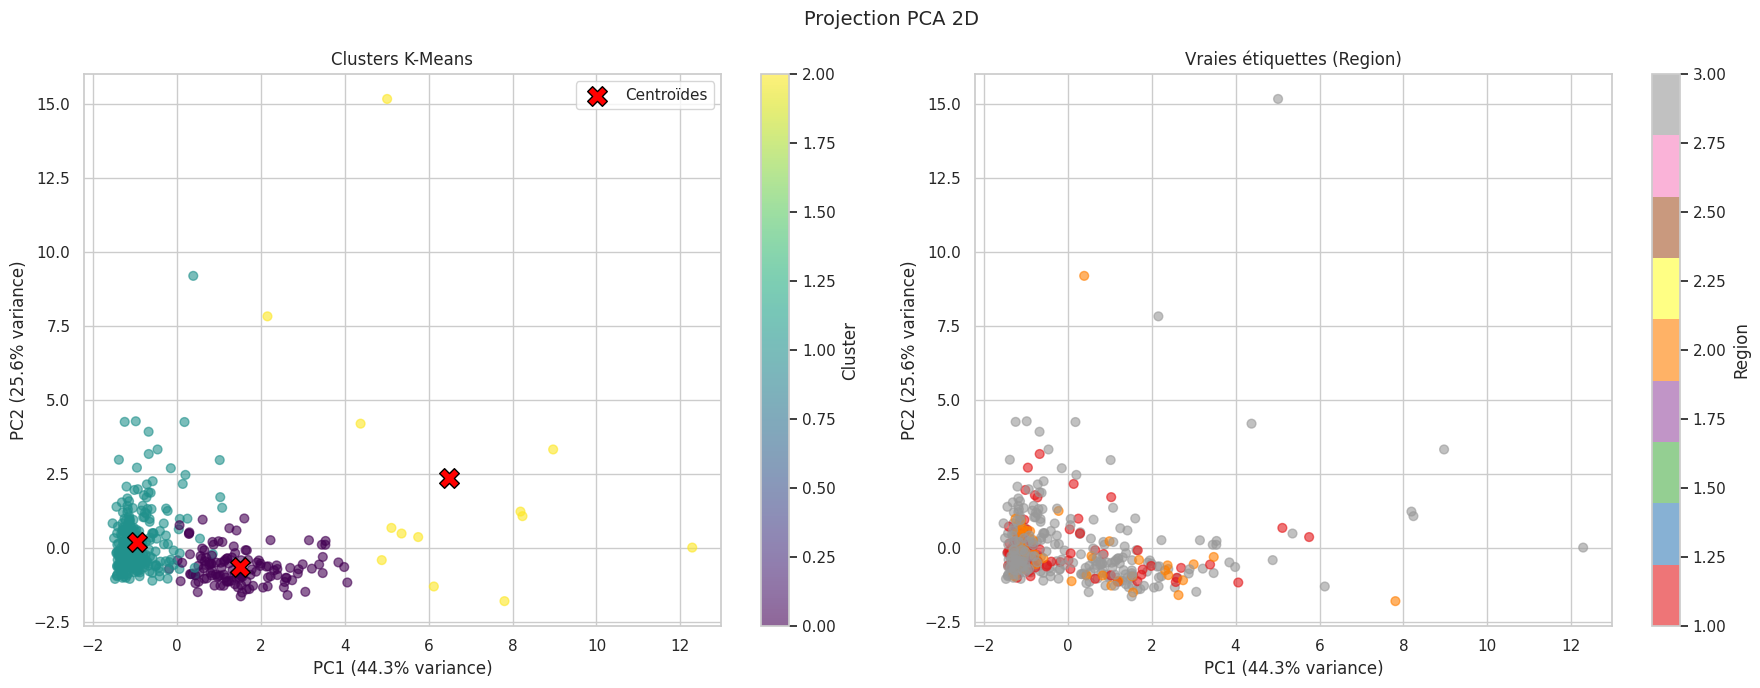

In [52]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Gauche : clusters K-Means ---
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", alpha=0.6, s=40)
centers_pca = pca.transform(model.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1], c="red", marker="X", s=200, edgecolors="black", label="Centroïdes")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax1.set_title("Clusters K-Means")
ax1.legend()
plt.colorbar(sc1, ax=ax1, label="Cluster")

# --- Droite : vraie étiquette Region ---
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=df_raw["Region"], cmap="Set1", alpha=0.6, s=40)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax2.set_title("Vraies étiquettes (Region)")
plt.colorbar(sc2, ax=ax2, label="Region")

plt.suptitle("Projection PCA 2D", fontsize=14)
plt.tight_layout()
plt.show()

### Matrice de contingence Region × Cluster
Lignes = vraie étiquette (`Region`), colonnes = cluster prédit par K-Means.

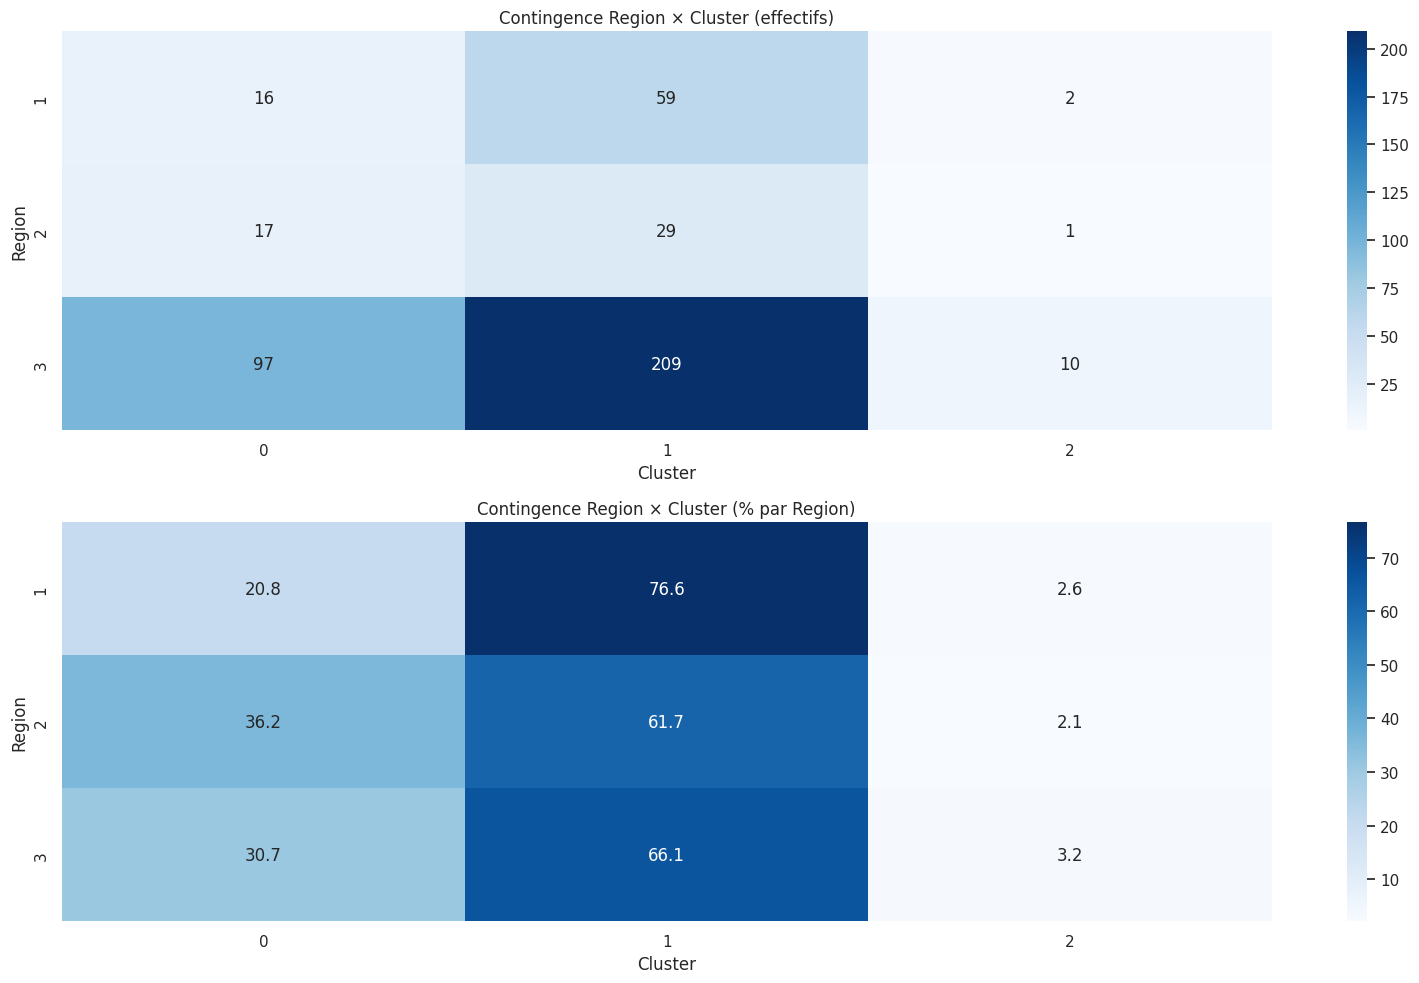

In [53]:
contingency = pd.crosstab(df_raw["Region"], df_raw["Cluster"],
                         rownames=["Region"], colnames=["Cluster"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Heatmap en valeurs absolues
sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues", ax=ax1)
ax1.set_title("Contingence Region × Cluster (effectifs)")

# Heatmap normalisée par ligne (% de chaque Region dans chaque Cluster)
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
sns.heatmap(contingency_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax2)
ax2.set_title("Contingence Region × Cluster (% par Region)")

plt.tight_layout()
plt.show()

## 3. Heatmap des centres de clusters

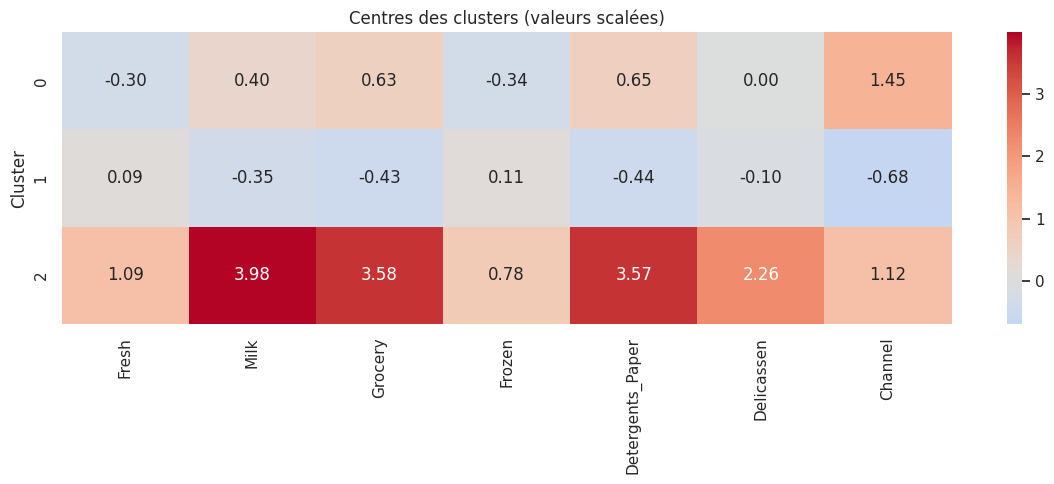

In [54]:
centers_df = pd.DataFrame(model.cluster_centers_, columns=df_scaled.columns)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(centers_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Centres des clusters (valeurs scalées)")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

## 4. Répartition des clusters

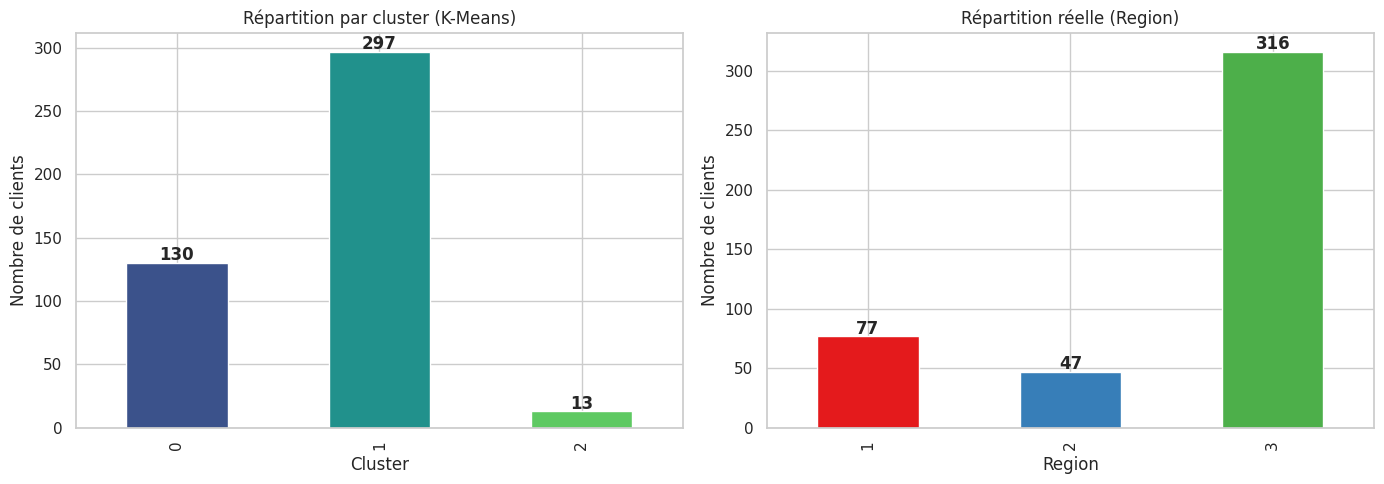

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gauche : répartition par cluster K-Means ---
cluster_counts = pd.Series(labels).value_counts().sort_index()
cluster_counts.plot(kind="bar", color=sns.color_palette("viridis", len(cluster_counts)), ax=ax1)
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Nombre de clients")
ax1.set_title("Répartition par cluster (K-Means)")
for i, v in enumerate(cluster_counts):
    ax1.text(i, v + 2, str(v), ha="center", fontweight="bold")

# --- Droite : répartition réelle par Region ---
region_counts = df_raw["Region"].value_counts().sort_index()
region_counts.plot(kind="bar", color=sns.color_palette("Set1", len(region_counts)), ax=ax2)
ax2.set_xlabel("Region")
ax2.set_ylabel("Nombre de clients")
ax2.set_title("Répartition réelle (Region)")
for i, v in enumerate(region_counts):
    ax2.text(i, v + 2, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Historique des runs MLflow

Récupération de **tous les runs** de l'expérience avec leurs paramètres et métriques.

In [56]:
from src.train import MLFLOW_EXPERIMENT

experiment = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
all_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
)

# Afficher le tableau des runs
cols = ["run_id", "start_time", "params.n_clusters", "params.n_samples",
        "metrics.inertia", "metrics.silhouette_score"]
display_cols = [c for c in cols if c in all_runs.columns]
all_runs[display_cols].head(10)

,run_id,start_time,params.n_clusters,params.n_samples,metrics.inertia,metrics.silhouette_score
0,ee1570e6b6c147a7aeb9751e24887d53,2026-03-11 09:44:21.240000+00:00,3,440,1711.506578,0.43916


In [57]:
# Évolution des métriques au fil des runs
if len(all_runs) > 1:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    all_runs_sorted = all_runs.sort_values("start_time")
    run_idx = range(len(all_runs_sorted))

    ax1.plot(run_idx, all_runs_sorted["metrics.inertia"], "bo-")
    ax1.set_xlabel("Run #")
    ax1.set_ylabel("Inertie")
    ax1.set_title("Inertie par run")

    ax2.plot(run_idx, all_runs_sorted["metrics.silhouette_score"], "ro-")
    ax2.set_xlabel("Run #")
    ax2.set_ylabel("Silhouette Score")
    ax2.set_title("Silhouette Score par run")

    plt.tight_layout()
    plt.show()
else:
    print("Un seul run disponible — lancez train.py avec différents k pour comparer.")

Un seul run disponible — lancez train.py avec différents k pour comparer.
